In [1]:
import pandas as pd
import seaborn as sns
sns.set_theme(font='helvetica', style='white',)
import matplotlib.pyplot as plt
import numpy as np
import json
from EvaluationTools import *

In [2]:
sets=['bars','ccas','cnrs']
qs=json.load(open('/Users/rm026/Documents/code/reviewpyper/extraction_questions.json'))

# qs['cnrs']={long:short for long, short in qs['cnrs'].items() if ('psychosis b' not in short and 'social' not in short)}

q_sets={}
qs_expls={}
non_cnrs=[]
cnrs=[]
for set in sets:
    q_sets[set]=list(qs[set].values())
    for long_q, short_q in qs[set].items():
        if set!='cnrs':
            non_cnrs.append(short_q)
            non_cnrs.append(f"explanation: {short_q}")
        else:
            cnrs.append(short_q)
            cnrs.append(f"explanation: {short_q}")
        qs_expls.update({long_q: short_q, f"EXPLANATION: {long_q}":f"explanation: {short_q}"})

In [3]:
# ai_expl=pd.read_csv('/Users/rm026/Documents/schmahmann/schmahmann_output_w_unknown/master_list_after_combination_similarities_fixed.csv')
# ai_expl=ai_expl[['MRN']+non_cnrs]
df=pd.read_csv('/Users/rm026/Documents/schmahmann/schmahmann_gpt5_fixed/master_list.csv')
df.drop(columns=['inclusion_1','Explanation: inclusion_1','filepath'], inplace=True)
# run_2.columns=["MRN"]+cnrs+['similarities','explanation: similarities']
# ai_expl.drop(columns=['similarities', 'explanation: similarities'], inplace=True)
# df=ai_expl.merge(gpt5, on='MRN',)
# df=df[['MRN']+list(qs_expls.values())]
# df.to_csv('/Users/rm026/Documents/schmahmann/schmahmann_gpt5/schmahmann_bars_ccas_cnrs_master_list.csv', index=False)
# df

In [4]:
gt=pd.read_csv('/Users/rm026/Documents/schmahmann/schmahmann_ground_truth_bars_ccas_cnrs.csv',)
ai=df[[col for col in df.columns if not col.startswith('Explanation:') or col=='MRN']]
merged=ai.merge(gt,on='MRN',suffixes=('_ai','_gt'))
merged

,MRN,gait_ai,heel–shin_ai,speech_ai,oculomotor_ai,finger-nose_ai,semantic fluency_ai,phonemic fluency_ai,category switching_ai,verbal registration_ai,...,psychosis b26_gt,psychosis b27_gt,social a28_gt,social a29_gt,social a30_gt,social a31_gt,social b32_gt,social b33_gt,social b34_gt,social b35_gt
0,956657,2.0,2.0,2.0,2.0,2.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1175258,2.0,2.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1315351,2.0,2.0,2.0,2.0,2.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1355923,2.0,2.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1798457,2.0,1.0,1.0,2.0,2.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,8231339,2.0,2.0,2.0,2.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
81,8254224,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
82,8344492,2.0,2.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
83,8346686,2.0,1.0,1.0,2.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
pal={'Motor':'#1F77B4', 'Cognitive':'#D62728', "Emotional":'#9467BD','bars':'#1F77B4', 'ccas':'#D62728', "cnrs":'#9467BD'}

In [6]:
pct_w_something={}
for set, qs in q_sets.items():
    sub_df=gt[qs]
    pct_w_something[set]=1-(sub_df.sum(axis=1).value_counts().get(0,0)/len(ai))
pct_w_something


{'bars': 1.0, 'ccas': 1.0, 'cnrs': np.float64(0.9176470588235294)}

In [7]:
yeses={'bars':[],'ccas':[], 'cnrs':[]}
for i, row in merged.iterrows():
    for set in sets:
        gt_row=row[[q+"_gt" for q in q_sets[set]]]

        counts=gt_row.value_counts()
        if counts.get(2,0)==0:
            proportion_yes=0
        else:
            proportion_yes=counts.get(2,0)/(counts.get(1,0)+counts.get(2,0))
        yeses[set].append(proportion_yes)

merged['bars_proportion_yes']=yeses['bars']
merged['ccas_proportion_yes']=yeses['ccas']
merged['cnrs_proportion_yes']=yeses['cnrs']
merged[['bars_proportion_yes','ccas_proportion_yes','cnrs_proportion_yes']]

,bars_proportion_yes,ccas_proportion_yes,cnrs_proportion_yes
0,1.0,0.5,0.142857
1,0.8,0.0,0.000000
2,1.0,0.0,0.200000
3,1.0,0.0,1.000000
4,0.6,0.5,0.666667
...,...,...,...
80,1.0,0.0,0.000000
81,0.0,0.0,0.000000
82,1.0,0.0,0.000000
83,0.4,0.0,0.000000


/var/folders/18/_vyb12pj2pn9yc0162_pk3cc0000gp/T/ipykernel_83132/3569989248.py:11: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  hist2.legend(hist1.get_legend_handles_labels()+hist2.get_legend_handles_labels()+hist3.get_legend_handles_labels(),


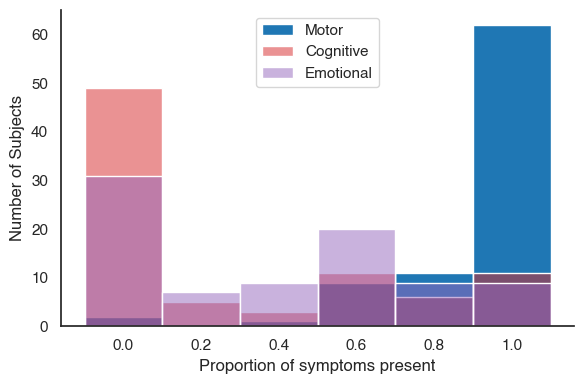

In [8]:
# pal={'Motor':'#1F77B4', 'Cognitive':'#D62728', "Emotional":'#9467BD'}
plt.figure(figsize=(6,4))
hist_dat=pd.DataFrame({'set':['Motor']*len(merged)+['Cognitive']*len(merged)+['Emotional']*len(merged),
                       'proportion_yes':list(merged['bars_proportion_yes'])+list(merged['ccas_proportion_yes'])+list(merged['cnrs_proportion_yes'])})
# hist=sns.histplot(data=hist_dat, x='proportion_yes', hue='set', alpha=0.6, palette=['#1F77B4','#D62728'])
hist1=sns.histplot(x=merged['bars_proportion_yes'], hue=['Motor']*len(merged), alpha=1, palette=pal, bins=np.arange(-0.1,1.1,0.2))
hist2=sns.histplot(x=merged['ccas_proportion_yes'], hue=['Cognitive']*len(merged),alpha=0.5, palette=pal, bins=np.arange(-0.1,1.1,0.2))
hist3=sns.histplot(x=merged['cnrs_proportion_yes'], hue=['Emotional']*len(merged), alpha=0.5, palette=pal, bins=np.arange(-0.1,1.1,0.2))
hist2.set_xlabel('Proportion of symptoms present')
hist2.set_ylabel('Number of Subjects')
hist2.legend(hist1.get_legend_handles_labels()+hist2.get_legend_handles_labels()+hist3.get_legend_handles_labels(), 
             labels=['Motor','Cognitive', "Emotional"], loc='upper center')
sns.despine()
plt.tight_layout()
plt.savefig(f'/Users/rm026/Documents/schmahmann/plots/symptom_proportion_histogram_consistent_bins_gpt5.svg')

In [9]:
n_known={}
for set in sets:
    total=0
    for q in q_sets[set]:
        num_zeros = gt[q].value_counts()[0] if 0 in gt[q].value_counts() else 0
        total+=len(gt)-num_zeros
    if set=='cnrs':
        n_known[set]=total/(35*len(gt))
    else:
        n_known[set]=total/(len(q_sets[set])*len(gt))
n_known

{'bars': 1.0,
 'ccas': np.float64(0.2847058823529412),
 'cnrs': np.float64(0.19058823529411764)}

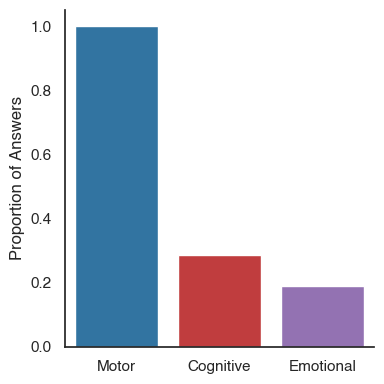

In [ ]:
labels=['Motor', 'Cognitive', 'Emotional']
plt.figure(figsize=(4,4))
bar=sns.barplot(x=labels, hue=labels,y=[1,n_known['ccas'],n_known['cnrs']], palette=pal)
bar.set_ylabel('Proportion of Answers')


sns.despine()
plt.tight_layout()
plt.savefig(f'/Users/rm026/Documents/schmahmann/plots/known_questions_proportion_gpt5.svg')

In [11]:
bars_conf=np.array([[0,0,0],
                    [0,0,0],
                    [0,0,0]])

for q in q_sets['bars']:
    bars_conf+=confusion_matrix(merged[q+'_gt'],merged[q+'_ai'])

bars_df=pd.DataFrame(bars_conf,columns=['Predict yes','Predict no','Predict unknown'],index=['Truth yes','Truth no','Truth unknown'])
bars_df, ignore_ground_truth_unknown(bars_conf)

(               Predict yes  Predict no  Predict unknown
 Truth yes              371           6                6
 Truth no                 2          40                0
 Truth unknown            0           0                0,
 array([[371,   6,   6],
        [  2,  40,   0]]))

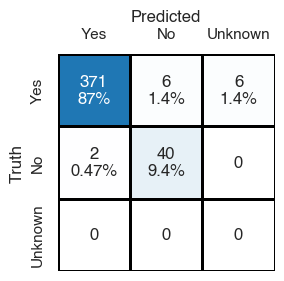

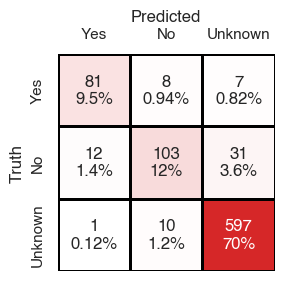

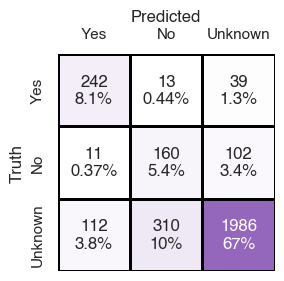

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

for set in sets:

    myconf=np.array([[0,0,0],
                    [0,0,0],
                    [0,0,0]])

    for q in q_sets[set]:
        myconf+=confusion_matrix(merged[q+'_gt'],merged[q+'_ai'])
    mycmap = LinearSegmentedColormap.from_list(
        "white_to_blue",
        ["#ffffff", pal[set]]
    )
    plot_conf_matrix(myconf, cmap=mycmap, filename=f'/Users/rm026/Documents/schmahmann/plots/{set}_confusion_matrix_gpt5.svg')

In [13]:
confusions={}
stats={}
ignoring_unk={}

for set in sets:
    confusions[set]={}
    ignoring_unk[set]={}
    for q in q_sets[set]:
        conf_matrix=confusion_matrix(merged[q+'_gt'], merged[q+'_ai'])
        confusions[set][q]=conf_matrix
        ignoring_unk[set][q]=ignore_ground_truth_unknown(conf_matrix)

    stats[set]=statistical_df(ignoring_unk[set],)


/Users/rm026/Documents/code/ReviewPyper/dev_tools/EvaluationTools.py:32: RuntimeWarning: invalid value encountered in scalar divide
  accuracy=good_answers/total_questions
/Users/rm026/Documents/code/ReviewPyper/dev_tools/EvaluationTools.py:43: RuntimeWarning: invalid value encountered in scalar divide
  return true_negatives/ground_truth_neg
/Users/rm026/Documents/code/ReviewPyper/dev_tools/EvaluationTools.py:38: RuntimeWarning: invalid value encountered in scalar divide
  return true_positives/ground_truth_pos
/Users/rm026/Documents/code/ReviewPyper/dev_tools/EvaluationTools.py:48: RuntimeWarning: invalid value encountered in scalar divide
  return true_positives/predicted_positives
/Users/rm026/Documents/code/ReviewPyper/dev_tools/EvaluationTools.py:53: RuntimeWarning: invalid value encountered in scalar divide
  return true_negatives/predicted_negatives


In [14]:
stats['cnrs']

,question,accuracy,specificity,sensitivity,positive predictive power,negative predictive power
0,attention a1,0.767442,0.500000,0.896552,1.000000,0.875000
1,attention a2,0.500000,0.000000,0.545455,1.000000,NaN
2,attention a3,0.600000,0.000000,0.750000,0.750000,0.000000
3,attention a4,0.500000,NaN,0.500000,1.000000,0.000000
4,attention a5,NaN,NaN,NaN,NaN,NaN
5,attention b6,1.000000,1.000000,1.000000,1.000000,1.000000
6,attention b7,0.750000,NaN,0.750000,1.000000,NaN
7,attention b8,0.818182,0.000000,0.900000,0.900000,NaN
8,attention b9,0.571429,NaN,0.571429,1.000000,NaN
9,emotion a10,0.636364,0.000000,0.777778,1.000000,NaN


/var/folders/18/_vyb12pj2pn9yc0162_pk3cc0000gp/T/ipykernel_83132/2350625667.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar1=sns.barplot(data=accdf,x='set',y='accuracy',  palette=pal.values(),)
/var/folders/18/_vyb12pj2pn9yc0162_pk3cc0000gp/T/ipykernel_83132/2350625667.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  bar1.set_xticklabels(labels)


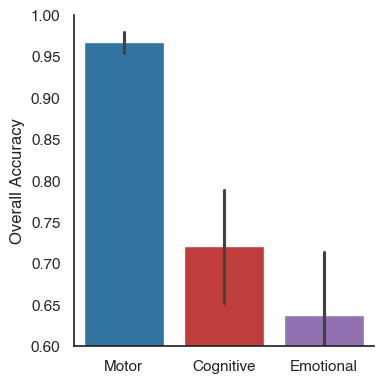

In [23]:
setstuff=[]
ques=[]
acc=[]
for thing in sets:
    setstuff+=[thing]*len(stats[thing])
    acc+=stats[thing]['accuracy'].values.tolist()

accdf=pd.DataFrame()
accdf['set']=setstuff
accdf['accuracy']=acc

labels=['Motor', 'Cognitive', 'Emotional']
plt.figure(figsize=(4,4))
bar1=sns.barplot(data=accdf,x='set',y='accuracy',  palette=pal.values(),)

bar1.set_ylabel('Overall Accuracy')

plt.ylim(.6,1)
import matplotlib.patches as patches

bar1.set_xticklabels(labels)
bar1.set_xlabel('')

sns.despine()
plt.tight_layout()
plt.savefig(f'/Users/rm026/Documents/schmahmann/plots/total_accuracy_gpt5.svg')

In [16]:
accdf

,set,accuracy
0,bars,0.976471
1,bars,0.976471
2,bars,0.952941
3,bars,0.988235
4,bars,0.941176
5,bars,0.967059
6,ccas,0.571429
7,ccas,0.695652
8,ccas,0.692308
9,ccas,0.757576


In [17]:
score_names=['accuracy','sensitivity','specificity','positive predictive power', 'negative predictive power']


dfs={}
for set in sets:

    q=[]
    stat_names=[]
    values=[]
    for i,row in stats[set].iterrows():
        for stat in score_names:
            q.append(row['question'])
            stat_names.append(stat.title())
            values.append(row[stat])
    dfs[set]=pd.DataFrame({'question':q, 'statistic':stat_names, 'value':values})
dfs['ccas']

,question,statistic,value
0,semantic fluency,Accuracy,0.571429
1,semantic fluency,Sensitivity,0.769231
2,semantic fluency,Specificity,0.400000
3,semantic fluency,Positive Predictive Power,0.909091
4,semantic fluency,Negative Predictive Power,0.857143
5,phonemic fluency,Accuracy,0.695652
6,phonemic fluency,Sensitivity,0.833333
7,phonemic fluency,Specificity,0.545455
8,phonemic fluency,Positive Predictive Power,0.909091
9,phonemic fluency,Negative Predictive Power,0.857143


In [18]:
import ptitprince as pt

def other_rc(stats_df, color, filename, ylims=None, debug=False):

    setstuff=[]
    cols=[]
    acc=[]
    for col in stats_df.columns[2:]:
        setstuff+=['ccas']*len(stats_df)
        cols+=[col]*len(stats_df)
        acc+=stats_df[col].values.tolist()
    accdf=pd.DataFrame()
    accdf['set']=setstuff
    accdf['scores']=acc
    accdf['scoretype']=cols
    if debug: 
        print(accdf[accdf['scoretype']=='specificity'])


    plt.figure(figsize=(4,4))
    rc=pt.RainCloud(data=accdf, y='scores',x='scoretype',hue='scoretype',
                bw=0.5, cut=0, orient='v', palette=[color]*4, width_viol=.5, width_box=.3,)
    rc.set_xticklabels(["Sensitivity","Specificity","NPV",'PPV'])

    rc.set_xlabel('')
    # auto_y_min, auto_y_max=rc.get_ylim()
    # rc.set_ylim((auto_y_min, 1))
    rc.set_ylim(ylims)
    rc.set_ylabel('Score')
    rc.grid(False)
    sns.despine()
    plt.tight_layout()
    plt.savefig(filename)


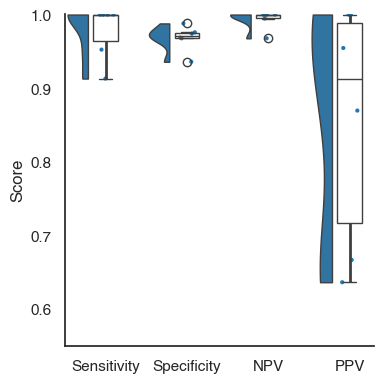

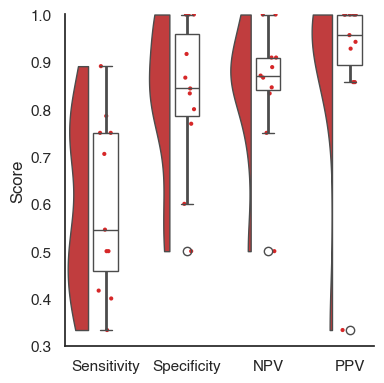

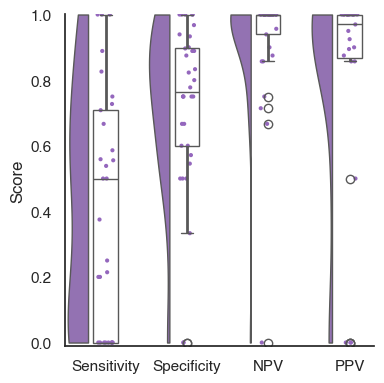

In [26]:
other_rc(stats['bars'], pal['Motor'], filename='/Users/rm026/Documents/schmahmann/plots/bars_raincloud_plot_gpt5.svg', ylims=(0.55,1.001))
other_rc(stats['ccas'], pal['Cognitive'], filename='/Users/rm026/Documents/schmahmann/plots/ccas_raincloud_plot_gpt5.svg', ylims=(.3,1.001))
other_rc(stats['cnrs'], pal['Emotional'], filename='/Users/rm026/Documents/schmahmann/plots/cnrs_raincloud_plot_gpt5.svg', ylims=(-0.01,1.001))


In [20]:
stats_table_data=[]

for set in sets:
    table_row=[set]
    for col in stats[set].columns:
        if col!='question':
            mean_stat=stats[set][col].mean()
            # print(set, col, mean_stat)
            table_row.append(mean_stat)
    stats_table_data.append(table_row)

stats_table=pd.DataFrame(stats_table_data, columns=['dataset']+list(stats['bars'].columns)[1:])
stats_table.round(3)

,dataset,accuracy,specificity,sensitivity,positive predictive power,negative predictive power
0,bars,0.967,0.978,0.968,0.994,0.855
1,ccas,0.721,0.598,0.830,0.852,0.898
2,cnrs,0.637,0.415,0.728,0.925,0.814


In [21]:
def human_checked(confusion):
    new=[[confusion[0,0]+confusion[0,1],0,confusion[0,2]],
         [0,confusion[1][0]+confusion[1][1],confusion[1,2]],
         [0,0,confusion[2].sum()]]

    return np.asarray(new)

human={}
for set, conf in zip(sets,[bars_conf,ccas_conf,cnrs_conf]):
    human[set]=human_checked(conf)
    print(set, accuracy(ignore_ground_truth_unknown(human[set])))


NameError: name 'ccas_conf' is not defined

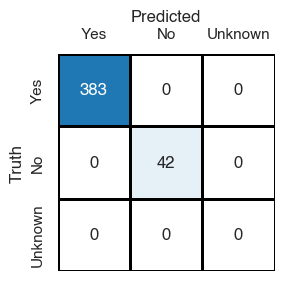

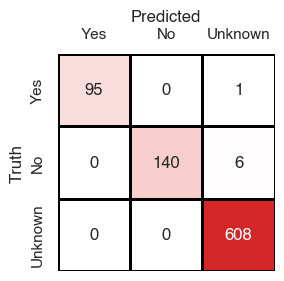

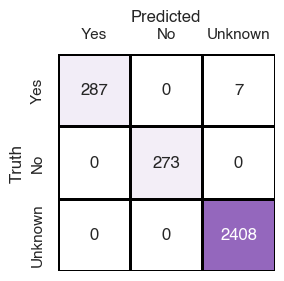

In [ ]:
cmaps={'bars':bars_cmap,
       'ccas':ccas_cmap,
       'cnrs':cnrs_cmap}

for set, conf in human.items():
    plot_conf_matrix(conf, cmap=cmaps[set], filename=f'/Users/rm026/Documents/schmahmann/plots/{set}_confusion_matrix_human_eval_gpt5.svg')

In [ ]:
post_confs={set:{q:ignore_ground_truth_unknown(human_checked(conf)) for q, conf in q_dict.items()} for set, q_dict in confusions.items()}
post_stats={set:statistical_df(q_dict) for set, q_dict in post_confs.items()}
post_stats['bars']

/Users/rm026/Documents/code/ReviewPyper/dev_tools/EvaluationTools.py:32: RuntimeWarning: invalid value encountered in scalar divide
  accuracy=good_answers/total_questions
/Users/rm026/Documents/code/ReviewPyper/dev_tools/EvaluationTools.py:43: RuntimeWarning: invalid value encountered in scalar divide
  return true_negatives/ground_truth_neg
/Users/rm026/Documents/code/ReviewPyper/dev_tools/EvaluationTools.py:38: RuntimeWarning: invalid value encountered in scalar divide
  return true_positives/ground_truth_pos
/Users/rm026/Documents/code/ReviewPyper/dev_tools/EvaluationTools.py:48: RuntimeWarning: invalid value encountered in scalar divide
  return true_positives/predicted_positives
/Users/rm026/Documents/code/ReviewPyper/dev_tools/EvaluationTools.py:53: RuntimeWarning: invalid value encountered in scalar divide
  return true_negatives/predicted_negatives


,question,accuracy,specificity,sensitivity,positive predictive power,negative predictive power
0,gait,1.0,1.0,1.0,1.0,1.0
1,heel–shin,1.0,1.0,1.0,1.0,1.0
2,speech,1.0,1.0,1.0,1.0,1.0
3,oculomotor,1.0,1.0,1.0,1.0,1.0
4,finger-nose,1.0,1.0,1.0,1.0,1.0
5,overall,1.0,1.0,1.0,1.0,1.0


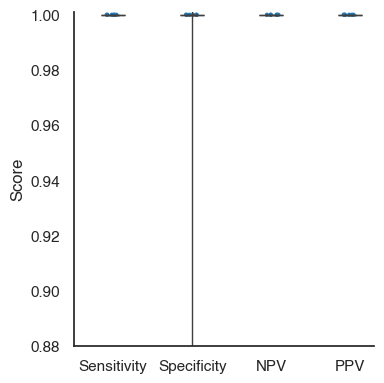

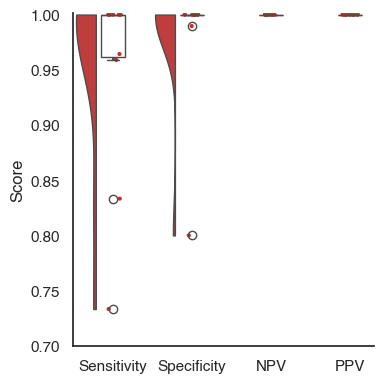

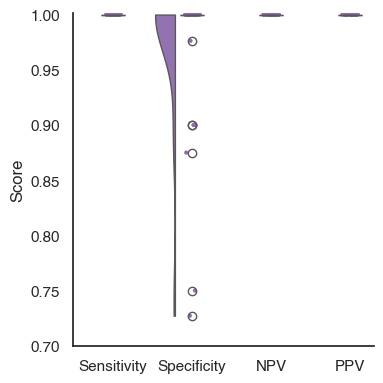

In [ ]:
other_rc(post_stats['bars'], pal['Motor'], filename='/Users/rm026/Documents/schmahmann/plots/post-eval_bars_raincloud_plot_gpt5.svg', ylims=(.88,1.001))
other_rc(post_stats['ccas'], pal['Cognitive'], filename='/Users/rm026/Documents/schmahmann/plots/post-eval_ccas_raincloud_plot_gpt5.svg', ylims=(.7,1.001))
other_rc(post_stats['cnrs'], pal['Emotional'], filename='/Users/rm026/Documents/schmahmann/plots/post-eval_cnrs_raincloud_plot_gpt5.svg', ylims=(.7,1.001))


In [ ]:
# stat_gains={}
# for set in sets:
#     gains=post_stats[set][score_names]-stats[set][score_names]
#     gains.insert(0,'question',stats[set]['question'])
#     stat_gains[set]=gains

# other_rc(stat_gains['bars'], pal['Motor'], filename='/Users/rm026/Documents/schmahmann/plots/diff_post-eval_bars_raincloud_plot_gpt5.svg', ylims=(-.01,.12))
# other_rc(stat_gains['ccas'], pal['Cognitive'], filename='/Users/rm026/Documents/schmahmann/plots/diff_post-eval_ccas_raincloud_plot_gpt5.svg', ylims=(-.01,.51))
# other_rc(stat_gains['cnrs'], pal['Emotional'], filename='/Users/rm026/Documents/schmahmann/plots/diff_post-eval_cnrs_raincloud_plot_gpt5.svg', ylims=(-.01,.51))

In [ ]:
sets

['bars', 'ccas', 'cnrs']

In [ ]:
pre_post_overall={}
for set in sets:
    new_df=pd.DataFrame()
    new_df['pre']=stats[set][stats[set]['question']=='overall'].squeeze()[1:]
    new_df['post']=post_stats[set][post_stats[set]['question']=='overall'].squeeze()[1:]
    pre_post_overall[set]=new_df
pre_post_overall['bars']

,pre,post
accuracy,0.992941,1.0
specificity,1.0,1.0
sensitivity,0.992167,1.0
positive predictive power,1.0,1.0
negative predictive power,0.933333,1.0


In [ ]:
import os 
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel
from matplotlib.colors import Colormap, LinearSegmentedColormap
import seaborn as sns

class PairSuperiorityPlot:
    def __init__(self, stat_array_1, stat_array_2, model1_name="X", model2_name="Y",title=None, out_dir=None,colormap=None,ylim=None):
        """
        Adapted/stolen from Calvin's CircuitPyper plotting functions. 
        Initializes the resampling plot object for visualizing paired delta statistics.
        This class is used to plot the paired delta between a statistic observed for 
        each resampling, and can visualize either bootstraps or permutations.
        Args:
            stat_array_1 (float): The statistical values 
            stat_array_2 (float): The R-squared value for the second region of interest (ROI).
            model1_name (str, optional): Name of the first model. Defaults to "X".
            model2_name (str, optional): Name of the second model. Defaults to "Y".
            stat (str, optional): The statistic name to be plotted. Defaults to "R²".
            out_dir (str, optional): Where to save. 
            observed_stat_array (float): The observed statistical values, where index 0 is the first observation and index 1 is the other.
            method (str): bootstrap | permtuation. If permutation, draws the distribution vertical line at the Delta's value. IF bootstrap, plot at 0.
        """
        self.stat_array_1 = stat_array_1
        self.stat_array_2 = stat_array_2 
        self.delta_array = self._stat_array_1 - self._stat_array_2
        self.model1_name = model1_name
        self.model2_name = model2_name
        self.out_dir = out_dir
        self.title=title
        # self.BLACK = '#211D1E'
        # self.GREY = '#8E8E8E'
        # self.WHITE = "#FFFFFF"
        if colormap is None:
            self.colormap=LinearSegmentedColormap.from_list("white_to_blue",["#ffffff", '#1F77B4'])
        else:
            self.colormap=colormap
        # self.colors={'before':colormap(.999),'slope':colormap(0.5),'after':colormap(.999)}
        # self.colors = self.compute_line_colors_abrupt()
        # self.colors=[self.BLACK,self.WHITE]
        self.ylim=ylim
        # self.prepare_out_dir()

    @property
    def stat_array_1(self):
        return self._stat_array_1

    @stat_array_1.setter
    def stat_array_1(self, value):
        value = np.array(value)  # Convert to numpy array
        if hasattr(self, '_stat_array_2') and len(value) != len(self._stat_array_2):
            raise ValueError("stat_array_1 and stat_array_2 must have the same length.")
        self._stat_array_1 = value

    @property
    def stat_array_2(self):
        return self._stat_array_2

    @stat_array_2.setter
    def stat_array_2(self, value):
        value = np.array(value)
        if hasattr(self, '_stat_array_1') and len(value) != len(self._stat_array_1):
            raise ValueError("stat_array_1 and stat_array_2 must have the same length.")
        self._stat_array_2 = value

    # def prepare_out_dir(self):
    #     if self.out_dir is not None:
    #         os.makedirs(self.out_dir, exist_ok=True)

    def plot_paired_slopes(self, ax):

        cm = sns.color_palette("tab10")
        self.plot_resample_dots(ax, self.stat_array_1, 1, cm)
        self.plot_resample_dots(ax, self.stat_array_2, 0, cm, legend=True)

        for i in range(len(self.stat_array_1)):
            ax.plot([0, 1], [self.stat_array_2[i], self.stat_array_1[i]], 
                    color=cm[i],linewidth=2, alpha=0.5)
            
        self.setup_slope_subplot(ax)

    def plot_resample_dots(self, ax, y_vals, x_coord, colormap, legend=False,size=150, edgecolor='white', alpha=0.9, linewidth=1.2, zorder=3):
        labels=["Accuracy","Sensitivity","Specificity","NPV",'PPV']
        for i, y in enumerate(y_vals):
            artist=ax.scatter([x_coord], [y], color=colormap[i],
                   edgecolors=edgecolor, linewidth=linewidth, alpha=alpha, s=size, marker='o', zorder=zorder, label=labels[i])
        if legend:
            ax.legend(labels,loc='lower right',fontsize='medium',frameon=False)

    def setup_slope_subplot(self, ax):
        ax.set_xticks([0, 1])
        ax.set_xticklabels([self.model2_name, self.model1_name])
        ax.set_title(self.title, fontsize=20)
        # ax.set_ylabel(f"", fontsize=20)
        ax.set_xlim(-0.5, 1.5)
        # y_max = max(np.max(self.stat_array_1), np.max(self.stat_array_2))
        # y_min = min(np.max(self.stat_array_1), np.max(self.stat_array_2))
        ax.set_ylim(self.ylim)
        ax.tick_params(labelsize=16)
        sns.despine(ax=ax)

    def annotate_paired_slopes(self, ax):
        t,p = ttest_rel(np.array(self.stat_array_1), np.array(self.stat_array_2))
        x_text = 0.05
        ha_text = 'left' 
        stat_text = f"t = {t:.4f}\np = {p:.4f}"
        ax.text(x_text, 0.95, stat_text, ha=ha_text, va='top', fontsize=14, color=self.BLACK, transform=ax.transAxes)

    def draw(self, verbose=True, ax_pair=None, save=True):
        
        abs_limit = np.max(np.abs(self.delta_array))

        fig, axes = plt.subplots(figsize=(4,4))

        self.plot_paired_slopes(axes)
        # Increase the width of the axis lines
        for spine in axes.spines.values():
            spine.set_linewidth(2)

        # Save the figure
        if save and self.out_dir is not None and ax_pair is None:
            # name = f'superiority_plot-{self.model1_name}-vs-{self.model2_name}_gpt5.svg'
            plt.savefig(self.out_dir, format='svg', bbox_inches='tight')
        if ax_pair is None:
            plt.tight_layout()
            if verbose:
                plt.show()


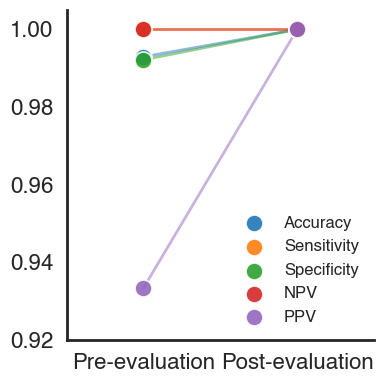

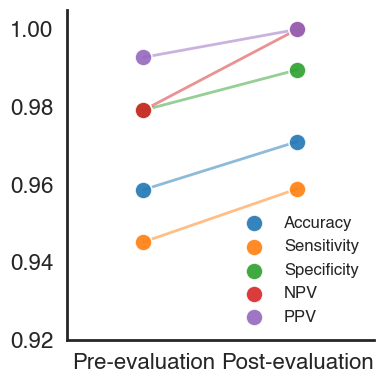

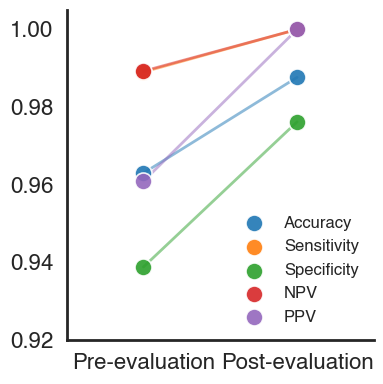

In [ ]:

# Load your CSV (paired columns)
# csv_path = '/Users/cu135/Partners HealthCare Dropbox/Calvin Howard/studies/memory_dbs/spreadsheets/master_list.csv'
# df = pd.read_csv(csv_path)

for set in sets:
    plotter = PairSuperiorityPlot(
        stat_array_1=pre_post_overall[set]['post'],
        stat_array_2=pre_post_overall[set]['pre'],
        model1_name='Post-evaluation',
        model2_name='Pre-evaluation',
        # title=f"Manual Evaluation Mean Improvement",
        out_dir=f'/Users/rm026/Documents/schmahmann/plots/{set}_pre-post_evaluation_improvement_gpt5.svg',
        colormap=cmaps[set],
        ylim=(.92,1.005)
    )
    plotter.draw()


In [ ]:
cm = sns.color_palette("tab10")
cm[0]

(0.12156862745098039, 0.4666666666666667, 0.7058823529411765)